# **Implement k-NN with sciki-learn**

This simple example aims to explain how to use `sciki-learn` to implement *k-NN* method for patter classification tasks, and then how to use `matplotlib` to visualize the results.

*Prerequisites*: basic understanding on *matplotlib* and *scikit-learn*.  


In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
print(iris.data)
print(iris.target)

X = iris.data[["sepal length (cm)", "sepal width (cm)"]]   # load only two features and discard the other two
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
0      0
1      0
2      0
3      0
4   

In [ ]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import confusion_matrix, accuracy_score

for k in range(1,20): 
  ## We are trying all the k values from 1 to 20. 
  classifier = KNeighborsClassifier(n_neighbors=k)    # build kNN
  classifier.fit(X_train, y_train)                    # train kNN (Passing the trainning data) 
  y_pred = classifier.predict(X_test)                 # predict on test set (Now we have the model and we want to perdict for the test. )

  accuracy = accuracy_score(y_test, y_pred)*100
  print(f":kNN accuracy (k={k}) is {accuracy:.2f}%")

The typical way of coding is to define the classifier, train it, and then test it. 

Finally, we use `matplotlib` to show the decision boundary of the k-NN method (when k=11). To do so, we first build the data processing pipeline in `sklearn` (with or without data normalization).

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# pipeline with data normalization
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=11))]
)
# pipeline without data normalization
# clf = Pipeline(
#      steps=[("knn", KNeighborsClassifier(n_neighbors=11))]
# )

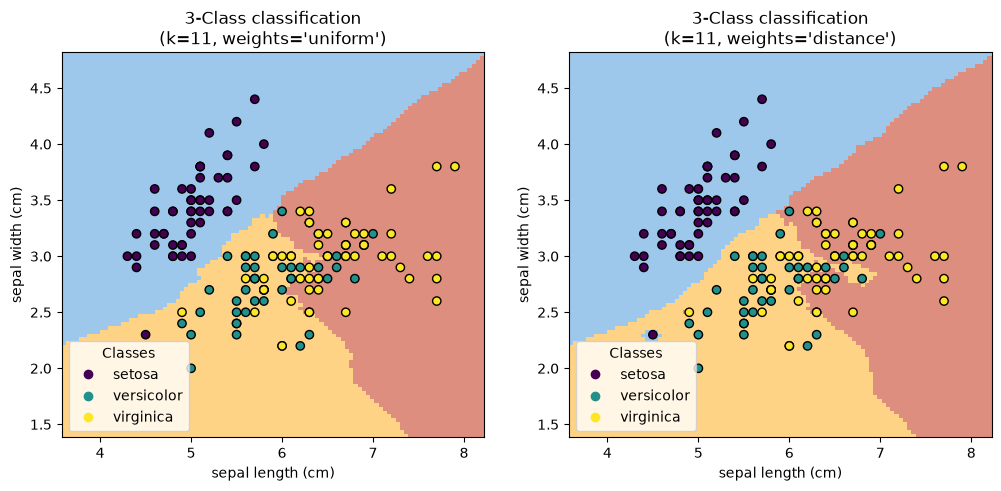

In [4]:
import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay

_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

### **Exercise**

1.   Modify the above code to re-implement k-NN using all four features in the iris dataset. Compare the accuracy with k-NN using only two features and explain the results.

2.   Try to use a different distance measures in k-NN (consider various values for `metric` in [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)). Compare its decision boundary with that of the default distance measure.  

3.   Explain the role of the hyper-parameter $k$ in the k-NN methods.  

4.   Explain why the data normalization changes the decision boundary of k-NN methods.


